In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [8]:
cost = pd.read_csv('COST.csv', index_col='Date', parse_dates=True)['Adj Close']
dg = pd.read_csv('DG.csv', index_col='Date', parse_dates=True)['Adj Close']
wmt = pd.read_csv('WMT.csv', index_col='Date', parse_dates=True)['Adj Close']
tgt = pd.read_csv('TGT.csv', index_col='Date', parse_dates=True)['Adj Close']


<AxesSubplot: xlabel='Date'>

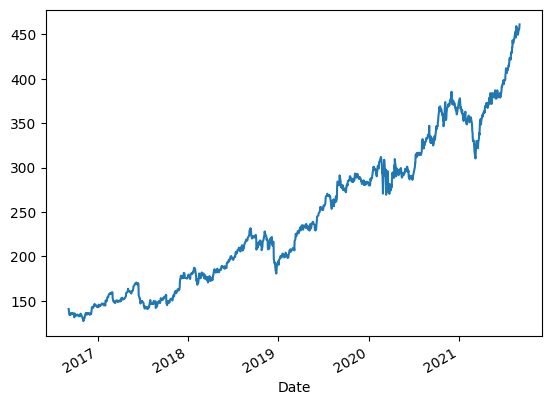

In [9]:
cost.plot()

In [10]:
stocks = pd.concat([cost, dg, wmt, tgt], axis=1)

In [12]:
stocks.columns = ['COST', 'DG', 'WMT', 'TGT']

In [14]:
stocks_returns = stocks.pct_change(1).dropna()

<AxesSubplot: xlabel='Date'>

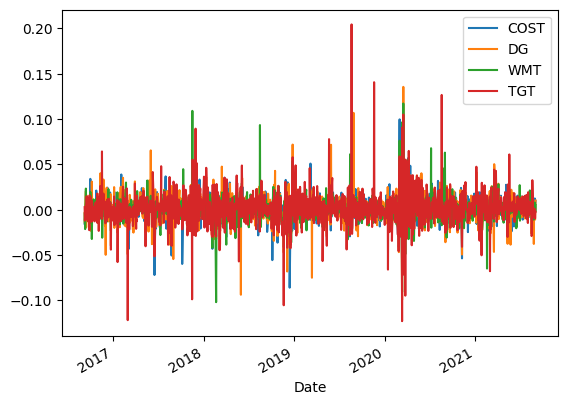

In [15]:
stocks_returns.plot()

<AxesSubplot: >

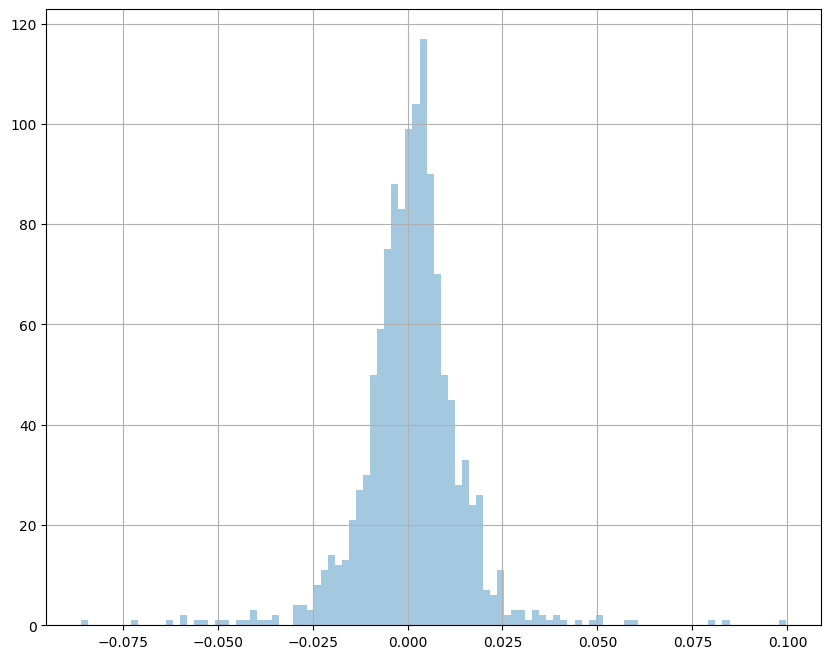

In [16]:
stocks_returns['COST'].hist(bins=100, label='COST', figsize=(10, 8), alpha=0.4)

In [17]:
stocks_returns

,COST,DG,WMT,TGT
Date,,,,
2016-09-07,-0.015311,-0.003472,-0.012877,0.002853
2016-09-08,-0.013942,-0.015052,-0.003191,-0.011949
2016-09-09,-0.018049,-0.001274,-0.021300,-0.006622
2016-09-12,0.006569,0.020475,0.023328,0.004347
2016-09-13,-0.006263,-0.019368,-0.006672,-0.005195
...,...,...,...,...
2021-08-27,0.002292,-0.002877,-0.005633,0.000884
2021-08-30,0.012413,0.000488,0.008053,0.000722
2021-08-31,-0.000965,-0.010871,0.002708,-0.009544


In [25]:
cumulative_return = ((1 + stocks_returns).cumprod() - 1)*100

<AxesSubplot: xlabel='Date'>

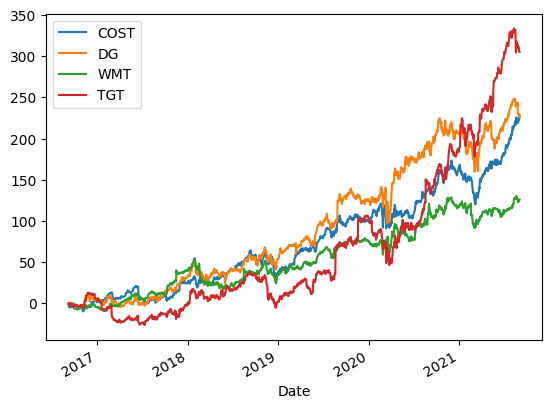

In [26]:
cumulative_return.plot()

In [27]:
n = len(stocks.columns)
equal_weights = n* [1/n]

In [28]:
equal_weights

[0.25, 0.25, 0.25, 0.25]

In [35]:
equal_returns = np.dot(equal_weights, stocks_returns.T)

In [36]:
equal_returns

array([-0.00720156, -0.01103371, -0.01181137, ..., -0.00466819,
       -0.00083906,  0.00573659])

In [41]:
cum_equal_weighted_returns = ((1+equal_returns).cumprod() - 1)*100

In [42]:
cum_equal_weighted_returns

array([ -0.72015577,  -1.81558123,  -2.97527339, ..., 232.41137617,
       232.1324627 , 234.03777089])

In [43]:
cewrp = pd.Series(cum_equal_weighted_returns, index=stocks_returns.index)

In [44]:
cewrp

Date
2016-09-07     -0.720156
2016-09-08     -1.815581
2016-09-09     -2.975273
2016-09-12     -1.647971
2016-09-13     -2.569954
                 ...    
2021-08-27    232.170295
2021-08-30    233.970413
2021-08-31    232.411376
2021-09-01    232.132463
2021-09-02    234.037771
Length: 1257, dtype: float64

<AxesSubplot: xlabel='Date'>

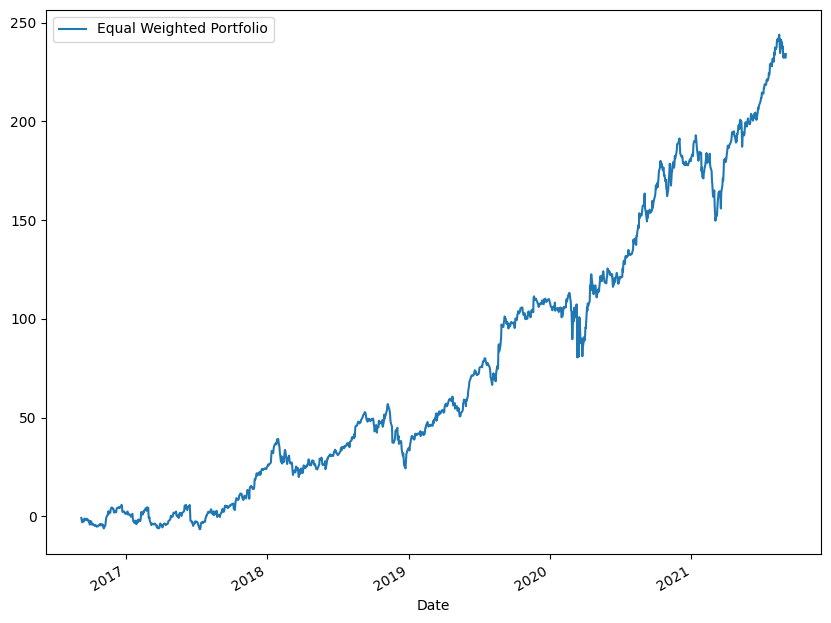

In [45]:
cewrp.plot(label='Equal Weighted Portfolio', figsize=(10, 8), legend=True)